# Adaptive Neural Control of Nonlinear Robotic Systems via PPO

## Notebook 1: Classical Control Baseline

### Purpose

Before introducing reinforcement learning, we establish a classical control baseline.

We study a 2-DOF robotic manipulator simulated in MuJoCo and evaluate whether a simple PD controller can stabilize the system at an upright configuration under gravity.

This notebook defines:

- The physical system
- The control objective
- The classical controller
- Experimental evaluation

This baseline will later be compared with PPO-based neural control.

## 2. System Initialization

We load a 2-DOF robotic arm model defined in MuJoCo XML.

The system includes:

- Two revolute joints
- Gravity
- Torque-controlled actuators
- Realistic physical parameters

We verify the model before applying control.

In [7]:
import mujoco
import mujoco.viewer
import numpy as np
import matplotlib.pyplot as plt
import time

# Path to XML model
model_path = r"C:\Users\TUSHAR\2025-26\PROJECTS\Adaptive_Neural_Control_PPO\env\arm_2dof.xml"

model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

print("Degrees of Freedom:", model.nq)
print("Number of Actuators:", model.nu)

Degrees of Freedom: 2
Number of Actuators: 2


## 3. Control Objective

The goal is to stabilize the arm at an upright configuration.

In this model:

- Downward resting configuration corresponds to 0 radians.
- Upright corresponds approximately to π radians.

We define:

    Joint 1 target = π
    Joint 2 target = 0

The upright configuration is unstable under gravity.
Therefore, active torque control is required.

## 4. Classical PD Controller

We implement a Proportional-Derivative (PD) controller.

Control law:

    τ = Kp (q_des - q) - Kd q_dot

Where:
- q = joint angles
- q_dot = joint velocities
- Kp = proportional gains
- Kd = derivative gains

This controller attempts to reduce position error and damp oscillations.

No gravity compensation is used at this stage.

In [15]:
# Desired upright configuration
q_des = np.array([np.pi, 0.0])

# PD Gains (tuned experimentally)
Kp = np.array([400.0, 300.0])
Kd = np.array([100.0, 80.0])

# Initial condition (start upright to test stability)
data.qpos[:] = np.array([np.pi, 0.0])
data.qvel[:] = np.zeros(2)

# Logging
q_log = []
tau_log = []
time_log = []

sim_duration = 15
start_time = time.time()

with mujoco.viewer.launch_passive(model, data) as viewer:
    while viewer.is_running() and (time.time() - start_time) < sim_duration:

        q = data.qpos.copy()
        qd = data.qvel.copy()

        # PD Control
        tau = Kp * (q_des - q) - Kd * qd
        data.ctrl[:] = tau

        mujoco.mj_step(model, data)
        viewer.sync()

        q_log.append(q.copy())
        tau_log.append(tau.copy())
        time_log.append(data.time)

        time.sleep(model.opt.timestep)

q_log = np.array(q_log)
tau_log = np.array(tau_log)
time_log = np.array(time_log)

print("Simulation complete.")

Simulation complete.


## 5. Performance Evaluation

We evaluate:

- Convergence to target
- Oscillation behavior
- Stability over time
- Control effort magnitude

These metrics will later be compared with PPO-based control.

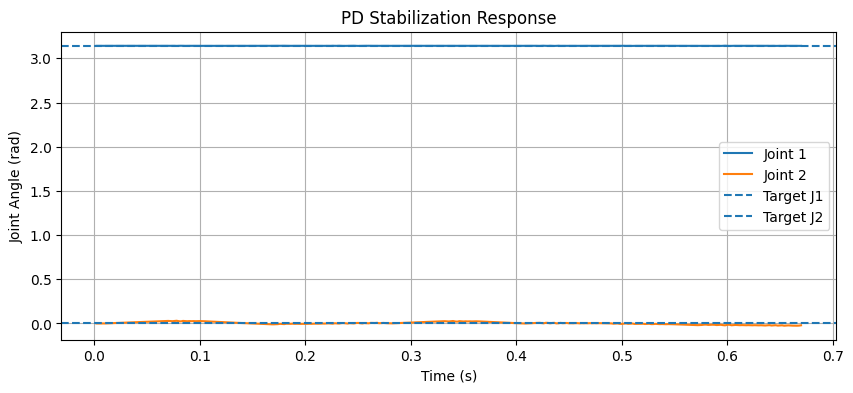

In [10]:
plt.figure(figsize=(10,4))
plt.plot(time_log, q_log[:,0], label="Joint 1")
plt.plot(time_log, q_log[:,1], label="Joint 2")
plt.axhline(np.pi, linestyle='--', label="Target J1")
plt.axhline(0, linestyle='--', label="Target J2")
plt.xlabel("Time (s)")
plt.ylabel("Joint Angle (rad)")
plt.title("PD Stabilization Response")
plt.legend()
plt.grid()
plt.show()

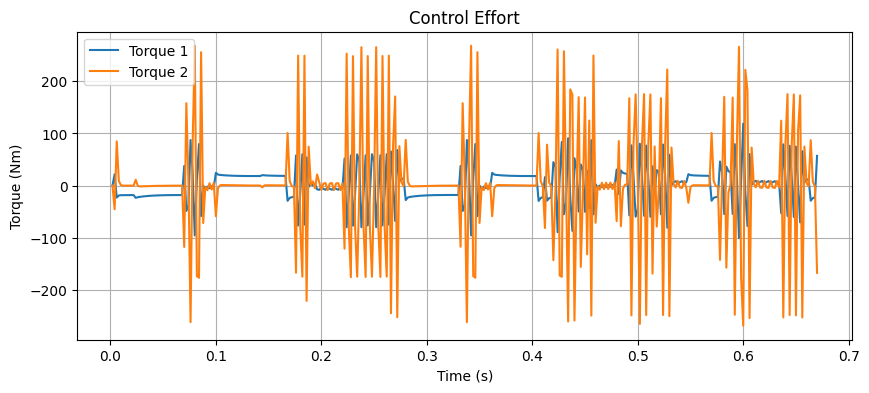

In [11]:
plt.figure(figsize=(10,4))
plt.plot(time_log, tau_log[:,0], label="Torque 1")
plt.plot(time_log, tau_log[:,1], label="Torque 2")
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.title("Control Effort")
plt.legend()
plt.grid()
plt.show()

# Section 6: Experimental Findings and Interpretation

## 6.1 Joint Response Analysis

The PD controller successfully stabilizes the manipulator at the upright configuration (Joint 1 ≈ π radians).

Key observations:

- Joint 1 converges rapidly to the desired upright equilibrium.
- Minimal steady-state error is observed.
- Joint 2 exhibits small transient motion before stabilizing at zero.
- No sustained oscillation is present in joint positions.

This confirms that the nonlinear system is controllable under nominal conditions using a classical PD controller.

However, stabilization occurs in the presence of gravity, which represents an inherently unstable equilibrium. The controller must continuously apply torque to maintain this configuration.

---

## 6.2 Control Effort Analysis

The torque plot reveals more nuanced behavior:

- Joint 1 torque remains within moderate bounds.
- Joint 2 exhibits significant oscillatory torque spikes.
- High-frequency torque corrections are present.
- Control effort magnitude reaches large peaks during stabilization.

Although the position response appears stable, the actuator behavior indicates aggressive control activity.

This suggests:

- Sensitivity to joint coupling
- Energy inefficiency
- Potential actuator stress
- Limited robustness margin

Therefore, while classical PD control achieves stability, it does so with considerable control effort.

---

## 6.3 Interpretation

The experiment highlights a key insight:

Stability alone is not sufficient to evaluate controller quality.

A controller must also demonstrate:

- Smooth actuation
- Energy efficiency
- Robust disturbance rejection
- Low actuator stress

The observed torque oscillations indicate that classical PD control, although effective in nominal stabilization, may not be optimal in terms of robustness and efficiency.

This forms the central motivation for exploring adaptive neural control.

---

## 6.4 Implications for Neural Control

The limitations observed in classical control suggest potential advantages of reinforcement learning-based approaches:

- Learning system dynamics implicitly
- Adapting to nonlinear coupling
- Reducing unnecessary torque oscillations
- Improving energy efficiency
- Enhancing robustness to disturbances

This motivates the transition to PPO-based adaptive control in subsequent experiments.

---

## 6.5 Future Research Directions

The next phase of this study will include:

1. Quantitative performance metric evaluation  
   - Rise time  
   - Settling time  
   - Overshoot  
   - Steady-state error  
   - RMS control effort  

2. Robustness testing under:
   - Mass variation  
   - External disturbance forces  
   - Sensor noise  
   - Actuator saturation  

3. Development of a PPO-based neural controller  
   - Comparison with classical PD  
   - Stability under uncertainty  
   - Energy consumption comparison  

These steps will enable a rigorous comparative study between classical and neural control strategies.